In [ ]:
import numpy as np

cesium_137_centroid = 450.58
cesium_137_fwhm = 33.2410

# Co-60 - 0,1
# Ba-133 - 2, 3, 4, 5
# Am-241 - 6
centroids = np.array(
    [
        802.56,
        906.28,
        # 193.81,
        211.85,
        249.12,
        # 309.75,
        91.62,
    ]
)

# # Index 2 is estimated visually 152 - 281
centroid_fwhm = np.array(
    [
        33.8384,
        46.6285,
        # 129.0,
        11.3521,
        18.4043,
        # 50.00,
        10.0873,
    ]
)

# Known emission energies for each radioactive source
energies = np.array(
    [
        1173,
        1332.5,
        # 80.998,
        302.85,
        356.0,
        # 383.85,
        59.6,
    ],
)

# centroids = np.array([])
# centroid_fwhm = np.array([])
# energies = np.array([])

centroids = np.array(
    [
        789.62,
        894.58,
        211.72,
        249.95,
        45.69,
    ]
)
centroid_fwhm = np.array(
    [
        42,
        44,
        50,
        20,
        5,
    ]
)
energies = np.array(
    [
        1173.0,  # Co-60
        1332.5,  # Co-60
        302.85,  # Ba-133
        356.0,  # Ba-133
        59.6,  # Am-241
    ]
)

# Co-60, Co-60p, Ba-133p, Cs-137

# centroids = np.array([680.33, 769.49, 215.34, 392.4])
# centroid_fwhm = np.array([29.9564, 31.1873, 16.8211, 28.4043])
# energies = np.array(
#     [
#         1173.2,
#         1332.5,
#         356.0,
#         661.6,
#     ]
# )

In [32]:
def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty


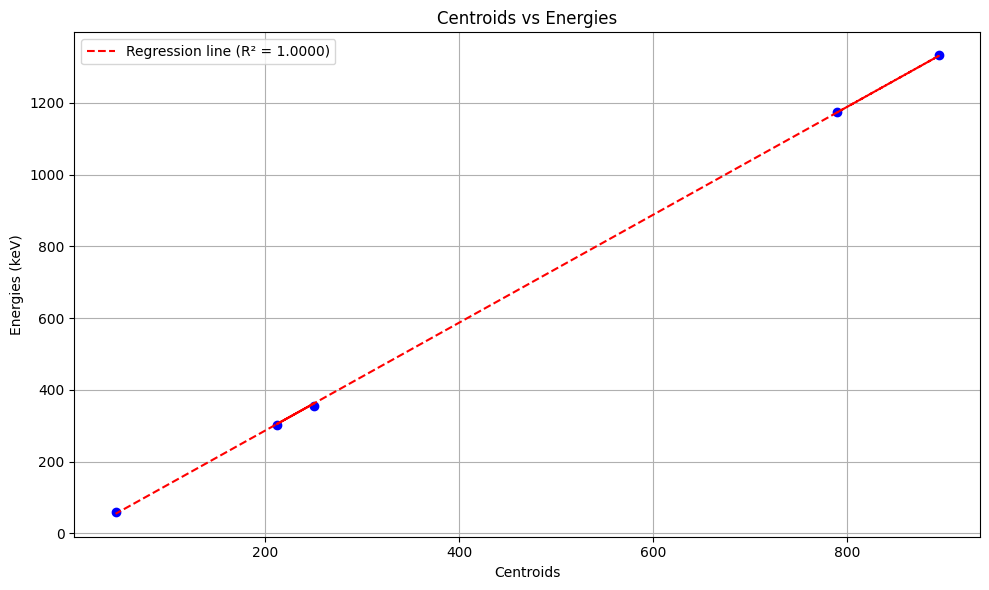

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with centroids and energies
df = pd.DataFrame(
    {
        "Centroids": centroids[: len(energies)],  # Ensure matching lengths
        "Energies": energies,
    }
)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(df["Centroids"], df["Energies"], color="blue", marker="o")
plt.xlabel("Centroids")
plt.ylabel("Energies (keV)")
plt.title("Centroids vs Energies")
plt.grid(True)

# Add a linear regression line
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["Centroids"], df["Energies"]
)
line = slope * df["Centroids"] + intercept
plt.plot(
    df["Centroids"],
    line,
    color="red",
    linestyle="--",
    label=f"Regression line (R² = {r_value**2:.4f})",
)
plt.legend()

plt.tight_layout()
plt.show()


In [34]:
# Define a function to convert channel number to energy using the regression weights
def channel_to_energy(channel):
    """
    Convert channel number to energy using the linear regression parameters.

    Parameters:
    -----------
    channel : float or array-like
        Channel number(s) to convert to energy

    Returns:
    --------
    float or array-like
        Corresponding energy value(s) in keV
    """
    return slope * channel + intercept


In [35]:
import pandas as pd

In [36]:
def process_spect(path: str):
    sdf = pd.read_csv("cs_spectrum.csv")
    sdf["channel"] = sdf["channel"].astype(int)
    sdf["energies"] = sdf["channel"].apply(channel_to_energy)

    plt.figure(figsize=(10, 6))
    plt.plot(sdf["energies"], sdf["frequency"], "o-")
    plt.xlabel("Energy (keV)", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.title("Frequency vs Energy", fontsize=16)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    return sdf

In [37]:
# process_spect("cs_spectrum.csv")

In [38]:
# NOTE: USE 1024 CHANNELS
# A,
unknown_a = np.array([89.42])
unknown_b = np.array([])
unknown_c = np.array([131.76, 169.86, 205.26, 245.36, 417.46])
unknown_fwhms = np.array([10.38, 12.38, 14.83, 17.57, 28.71])
unknown_c_upper = unknown_c + unknown_fwhms / 2
unknown_c_lower = unknown_c - unknown_fwhms / 2

unknown_d = np.array([])
unknown_energies = channel_to_energy(unknown_c)
upper_energies = channel_to_energy(unknown_c_upper)
lower_energies = channel_to_energy(unknown_c_lower)
uncs = (upper_energies - lower_energies) / 2

print(unknown_energies)
print(uncs)


[183.8270492  241.11810724 294.34916905 354.64763171 613.43479941]
[ 7.80421499  9.3079173  11.14995264 13.2100248  21.58564667]


In [39]:
channel_to_energy(77)

np.float64(101.4843106581574)

In [40]:
# Eu-152
#